In [1]:
# =========================================================
# CELL 1: SETUP ENV
# =========================================================
!pip -q install ultralytics seaborn pyyaml

import os, random, yaml, cv2, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import torch

from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print("Python ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python ready.


In [2]:
# =========================================================
# CELL 2: GPU + REPRODUCIBILITY
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

!nvidia-smi -L

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU 0: Tesla T4 (UUID: GPU-8e21eb95-870c-f45a-5f05-553f83f75688)
GPU 1: Tesla T4 (UUID: GPU-ca647b83-43da-7a3b-8cd8-12135df35ac0)


In [3]:
# =========================================================
# CELL 3: CREATE DATA YAML
# =========================================================
# Dataset bạn đã add vào Kaggle input:
# /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo

DATA_ROOT = Path("/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo")

cfg = {
    "path": str(DATA_ROOT),
    "train": "data/train/images",
    "val": "data/val/images",
    "test": "data/test/images",
    "names": ["smoke", "fire"],
    "nc": 2
}

yaml_path = Path("/kaggle/working/data_fire.yaml")
with open(yaml_path, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Saved:", yaml_path)
print(open(yaml_path).read())

Saved: /kaggle/working/data_fire.yaml
path: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
train: data/train/images
val: data/val/images
test: data/test/images
names:
- smoke
- fire
nc: 2



In [4]:
# =========================================================
# CELL 4: RESOLVE PATHS
# =========================================================
with open("/kaggle/working/data_fire.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)

ROOT = Path(data_cfg["path"])
TRAIN_IMG_DIR = ROOT / data_cfg["train"]
VAL_IMG_DIR   = ROOT / data_cfg["val"]
TEST_IMG_DIR  = ROOT / data_cfg["test"]

def image_dir_to_label_dir(img_dir: Path):
    return Path(str(img_dir).replace("/images", "/labels"))

TRAIN_LBL_DIR = image_dir_to_label_dir(TRAIN_IMG_DIR)
VAL_LBL_DIR   = image_dir_to_label_dir(VAL_IMG_DIR)
TEST_LBL_DIR  = image_dir_to_label_dir(TEST_IMG_DIR)

NAMES = data_cfg["names"]
NC = data_cfg["nc"]

print("ROOT:", ROOT)
for p in [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR, TEST_IMG_DIR, TEST_LBL_DIR]:
    print(p, "=>", p.exists())

ROOT: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images => True
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels => True
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images => True
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels => True
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images => True
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels => True


In [5]:
# =========================================================
# CELL 5: UTILS
# =========================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])

def corresponding_label_path(img_path: Path, labels_dir: Path):
    return labels_dir / (img_path.stem + ".txt")

def parse_yolo_label_file(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows

    with open(label_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    for i, ln in enumerate(lines):
        parts = ln.split()
        if len(parts) != 5:
            rows.append({"error": f"line_{i}: wrong_num_fields={len(parts)}", "raw": ln})
            continue
        try:
            cls, xc, yc, w, h = map(float, parts)
            rows.append({
                "class_id": int(cls),
                "xc": xc, "yc": yc, "w": w, "h": h,
                "error": None, "raw": ln
            })
        except:
            rows.append({"error": f"line_{i}: parse_error", "raw": ln})
    return rows

def validate_split(images_dir: Path, labels_dir: Path, split_name: str, nc: int):
    img_paths = list_images(images_dir)
    records = []

    for img_p in tqdm(img_paths, desc=f"Validating {split_name}"):
        lbl_p = corresponding_label_path(img_p, labels_dir)

        img = cv2.imread(str(img_p))
        if img is None:
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": "corrupt_image", "num_boxes": 0
            })
            continue

        h_img, w_img = img.shape[:2]
        parsed = parse_yolo_label_file(lbl_p)

        if not lbl_p.exists():
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": "missing_label_file", "num_boxes": 0, "img_w": w_img, "img_h": h_img
            })
            continue

        if len(parsed) == 0:
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": None, "error_detail": "empty_label_file", "num_boxes": 0,
                "img_w": w_img, "img_h": h_img
            })
            continue

        for row in parsed:
            if row.get("error"):
                records.append({
                    "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                    "error_type": "format_error", "error_detail": row["error"], "num_boxes": 0,
                    "img_w": w_img, "img_h": h_img
                })
                continue

            cls_id, xc, yc, w, h = row["class_id"], row["xc"], row["yc"], row["w"], row["h"]
            err = None
            if not (0 <= cls_id < nc):
                err = f"class_id_out_of_range:{cls_id}"
            elif not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                err = f"bbox_out_of_range"

            records.append({
                "split": split_name,
                "image_path": str(img_p),
                "label_path": str(lbl_p),
                "class_id": cls_id if err is None else None,
                "xc": xc if err is None else None,
                "yc": yc if err is None else None,
                "w": w if err is None else None,
                "h": h if err is None else None,
                "img_w": w_img, "img_h": h_img,
                "num_boxes": 1 if err is None else 0,
                "error_type": err
            })

    return pd.DataFrame(records)

In [6]:
# =========================================================
# CELL 5: UTILS
# =========================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])

def corresponding_label_path(img_path: Path, labels_dir: Path):
    return labels_dir / (img_path.stem + ".txt")

def parse_yolo_label_file(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows

    with open(label_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    for i, ln in enumerate(lines):
        parts = ln.split()
        if len(parts) != 5:
            rows.append({"error": f"line_{i}: wrong_num_fields={len(parts)}", "raw": ln})
            continue
        try:
            cls, xc, yc, w, h = map(float, parts)
            rows.append({
                "class_id": int(cls),
                "xc": xc, "yc": yc, "w": w, "h": h,
                "error": None, "raw": ln
            })
        except:
            rows.append({"error": f"line_{i}: parse_error", "raw": ln})
    return rows

def validate_split(images_dir: Path, labels_dir: Path, split_name: str, nc: int):
    img_paths = list_images(images_dir)
    records = []

    for img_p in tqdm(img_paths, desc=f"Validating {split_name}"):
        lbl_p = corresponding_label_path(img_p, labels_dir)

        img = cv2.imread(str(img_p))
        if img is None:
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": "corrupt_image", "num_boxes": 0
            })
            continue

        h_img, w_img = img.shape[:2]
        parsed = parse_yolo_label_file(lbl_p)

        if not lbl_p.exists():
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": "missing_label_file", "num_boxes": 0, "img_w": w_img, "img_h": h_img
            })
            continue

        if len(parsed) == 0:
            records.append({
                "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                "error_type": None, "error_detail": "empty_label_file", "num_boxes": 0,
                "img_w": w_img, "img_h": h_img
            })
            continue

        for row in parsed:
            if row.get("error"):
                records.append({
                    "split": split_name, "image_path": str(img_p), "label_path": str(lbl_p),
                    "error_type": "format_error", "error_detail": row["error"], "num_boxes": 0,
                    "img_w": w_img, "img_h": h_img
                })
                continue

            cls_id, xc, yc, w, h = row["class_id"], row["xc"], row["yc"], row["w"], row["h"]
            err = None
            if not (0 <= cls_id < nc):
                err = f"class_id_out_of_range:{cls_id}"
            elif not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                err = f"bbox_out_of_range"

            records.append({
                "split": split_name,
                "image_path": str(img_p),
                "label_path": str(lbl_p),
                "class_id": cls_id if err is None else None,
                "xc": xc if err is None else None,
                "yc": yc if err is None else None,
                "w": w if err is None else None,
                "h": h if err is None else None,
                "img_w": w_img, "img_h": h_img,
                "num_boxes": 1 if err is None else 0,
                "error_type": err
            })

    return pd.DataFrame(records)

In [7]:
# =========================================================
# CELL 6: VALIDATE DATASET
# =========================================================
train_df = validate_split(TRAIN_IMG_DIR, TRAIN_LBL_DIR, "train", NC)
val_df   = validate_split(VAL_IMG_DIR, VAL_LBL_DIR, "val", NC)
test_df  = validate_split(TEST_IMG_DIR, TEST_LBL_DIR, "test", NC)

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Total annotation rows:", len(full_df))
display(full_df.head())

print("\nError summary:")
display(full_df["error_type"].value_counts(dropna=False))

err_df = full_df[full_df["error_type"].notna()]
print("Unique problematic images:", err_df["image_path"].nunique())

Validating train:   0%|          | 0/14122 [00:00<?, ?it/s]

Validating val:   0%|          | 0/3099 [00:00<?, ?it/s]

Validating test:   0%|          | 0/4306 [00:00<?, ?it/s]

Total annotation rows: 36395


,split,image_path,label_path,error_type,error_detail,num_boxes,img_w,img_h,class_id,xc,yc,w,h
0,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,/kaggle/input/datasets/sayedgamal99/smoke-fire...,None,empty_label_file,0,1086,610,NaN,NaN,NaN,NaN,NaN
1,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,/kaggle/input/datasets/sayedgamal99/smoke-fire...,None,NaN,1,1103,598,1.0,0.216228,0.739130,0.136899,0.150502
2,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,/kaggle/input/datasets/sayedgamal99/smoke-fire...,None,NaN,1,1087,604,0.0,0.767249,0.288907,0.036799,0.054636
3,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,/kaggle/input/datasets/sayedgamal99/smoke-fire...,None,empty_label_file,0,1024,576,NaN,NaN,NaN,NaN,NaN
4,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,/kaggle/input/datasets/sayedgamal99/smoke-fire...,None,empty_label_file,0,1280,720,NaN,NaN,NaN,NaN,NaN



Error summary:


error_type
None                 36369
bbox_out_of_range       26
Name: count, dtype: int64

Unique problematic images: 26


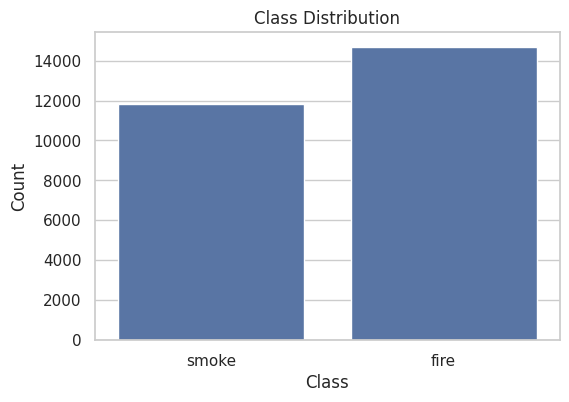

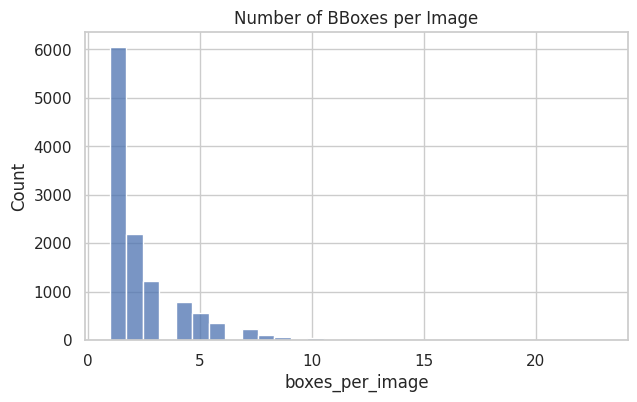

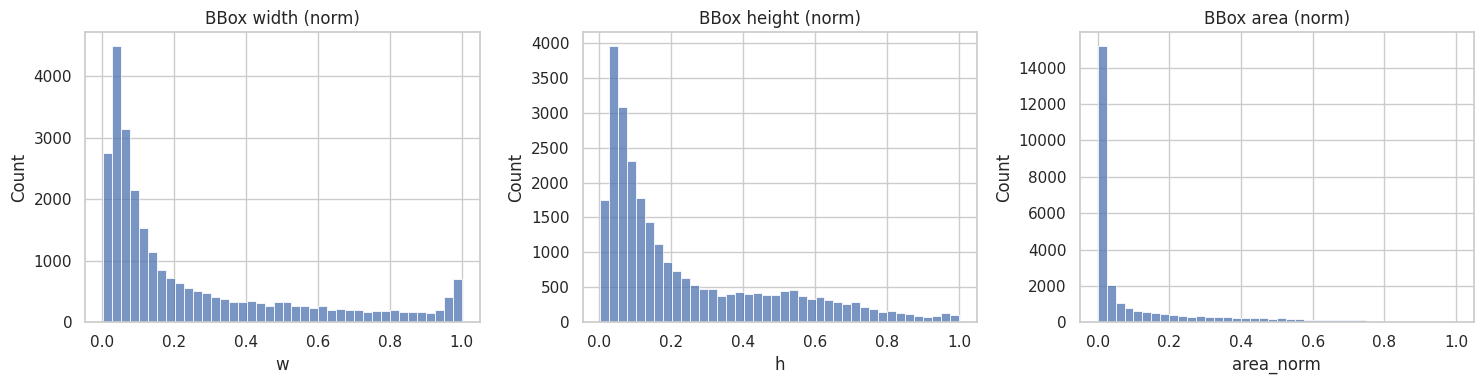

Suspect boxes: 1417


,split,image_path,class_name,w,h,area_norm,aspect_ratio
3362,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.013281,0.033333,0.000443,0.398438
3812,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.017969,0.027778,0.000499,0.646875
3831,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.016406,0.025000,0.000410,0.656250
3835,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.014063,0.027778,0.000391,0.506250
3841,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.013281,0.025000,0.000332,0.531250
4178,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,smoke,0.904545,0.978082,0.884720,0.924815
4349,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.010661,0.017429,0.000186,0.611674
4502,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.021875,0.022222,0.000486,0.984375
4503,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.020313,0.022222,0.000451,0.914062
4508,train,/kaggle/input/datasets/sayedgamal99/smoke-fire...,fire,0.015625,0.027778,0.000434,0.562500


In [8]:
# =========================================================
# CELL 7: EDA
# =========================================================
valid_boxes = full_df[(full_df["error_type"].isna()) & (full_df["num_boxes"] == 1)].copy()
valid_boxes["class_name"] = valid_boxes["class_id"].astype(int).map({0:"smoke", 1:"fire"})
valid_boxes["area_norm"] = valid_boxes["w"] * valid_boxes["h"]
valid_boxes["aspect_ratio"] = valid_boxes["w"] / valid_boxes["h"].clip(lower=1e-6)

# 1) Class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=valid_boxes, x="class_name", order=["smoke","fire"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2) BBoxes per image
boxes_per_image = valid_boxes.groupby(["split", "image_path"]).size().reset_index(name="boxes_per_image")
plt.figure(figsize=(7,4))
sns.histplot(boxes_per_image["boxes_per_image"], bins=30)
plt.title("Number of BBoxes per Image")
plt.show()

# 3) BBox width/height/area
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.histplot(valid_boxes["w"], bins=40, ax=axes[0]); axes[0].set_title("BBox width (norm)")
sns.histplot(valid_boxes["h"], bins=40, ax=axes[1]); axes[1].set_title("BBox height (norm)")
sns.histplot(valid_boxes["area_norm"], bins=40, ax=axes[2]); axes[2].set_title("BBox area (norm)")
plt.tight_layout()
plt.show()

# 4) Suspicious annotations (heuristic)
suspect = valid_boxes[
    (valid_boxes["area_norm"] < 0.0005) |
    (valid_boxes["area_norm"] > 0.8) |
    (valid_boxes["aspect_ratio"] > 10) |
    (valid_boxes["aspect_ratio"] < 0.1)
]
print("Suspect boxes:", len(suspect))
display(suspect[["split","image_path","class_name","w","h","area_norm","aspect_ratio"]].head(20))

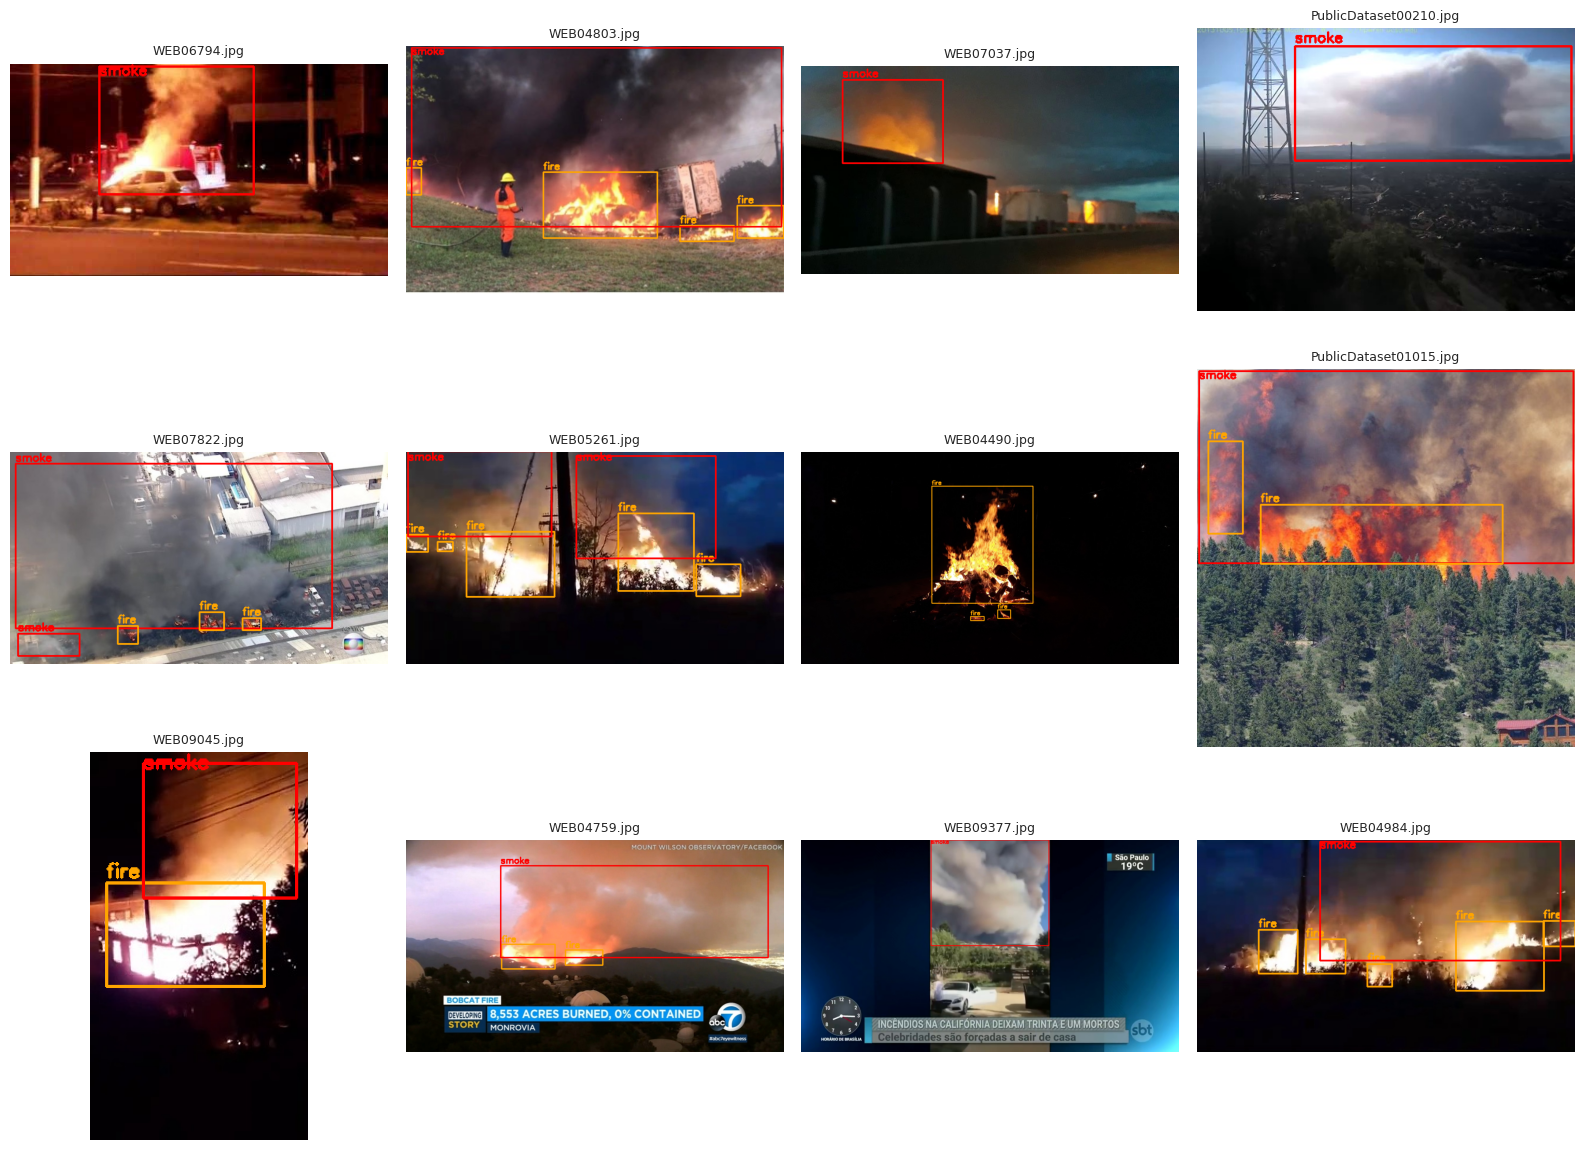

In [9]:
# =========================================================
# CELL 8: VISUALIZE BBOXES
# =========================================================
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w/2) * img_w)
    y1 = int((yc - h/2) * img_h)
    x2 = int((xc + w/2) * img_w)
    y2 = int((yc + h/2) * img_h)
    return x1, y1, x2, y2

def draw_image_with_boxes(img_path, rows, class_names):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for _, r in rows.iterrows():
        cls_id = int(r["class_id"])
        x1, y1, x2, y2 = yolo_to_xyxy(r["xc"], r["yc"], r["w"], r["h"], w, h)
        color = (255, 0, 0) if cls_id == 0 else (255, 165, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, class_names[cls_id], (x1, max(15, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

sample_imgs = valid_boxes[valid_boxes["split"]=="train"]["image_path"].drop_duplicates().sample(12, random_state=SEED).tolist()

fig, axes = plt.subplots(3,4, figsize=(16,12))
axes = axes.flatten()
for ax, ip in zip(axes, sample_imgs):
    rows = valid_boxes[valid_boxes["image_path"] == ip]
    vis = draw_image_with_boxes(Path(ip), rows, NAMES)
    ax.imshow(vis)
    ax.set_title(Path(ip).name, fontsize=9)
    ax.axis("off")

for i in range(len(sample_imgs), len(axes)):
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.yaml")  # scratch

results = model.train(
    data="/kaggle/working/data_fire.yaml",
    epochs=50,         
    patience=10,          
    imgsz=640,
    batch=16,     
    device=[0,1],
    workers=8,
    seed=42,
    deterministic=True,
    amp=True,
    project="/kaggle/working/runs",
    name="fire_smoke_yolo11n_scratch_es",

    # augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.05,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    # optimizer
    optimizer="SGD",
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fire.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_yolo11n_scratch_e

In [13]:
!ls -R /kaggle/working/runs


ls: cannot access '/kaggle/working/runs/fire_smoke_yolo11n_scratch/weights': No such file or directory


In [14]:
from ultralytics import YOLO

model = YOLO("yolo11n.yaml")   # scratch architecture
model.info()                   # tóm tắt layers/params
print(model.model)             # in full module tree

YOLO11n summary: 182 layers, 2,624,080 parameters, 2,624,064 gradients, 6.6 GFLOPs
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, a

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,8182.05,1.45406,1.24723,1.47666,0.72917,0.63642,0.70616,0.40144,1.29197,1.25256,1.28572,0.001090,0.001090,0.001090
46,47,8348.69,1.45920,1.23324,1.46066,0.72660,0.63748,0.70658,0.40267,1.29120,1.24609,1.28399,0.000892,0.000892,0.000892
47,48,8515.86,1.42280,1.20677,1.45595,0.72659,0.63936,0.70573,0.40289,1.29217,1.24581,1.28513,0.000694,0.000694,0.000694
48,49,8683.85,1.41806,1.18055,1.44584,0.73458,0.63549,0.70853,0.40402,1.29052,1.21765,1.28414,0.000496,0.000496,0.000496
49,50,8850.77,1.43871,1.18470,1.45413,0.73210,0.63194,0.70877,0.40387,1.28985,1.20909,1.28273,0.000298,0.000298,0.000298


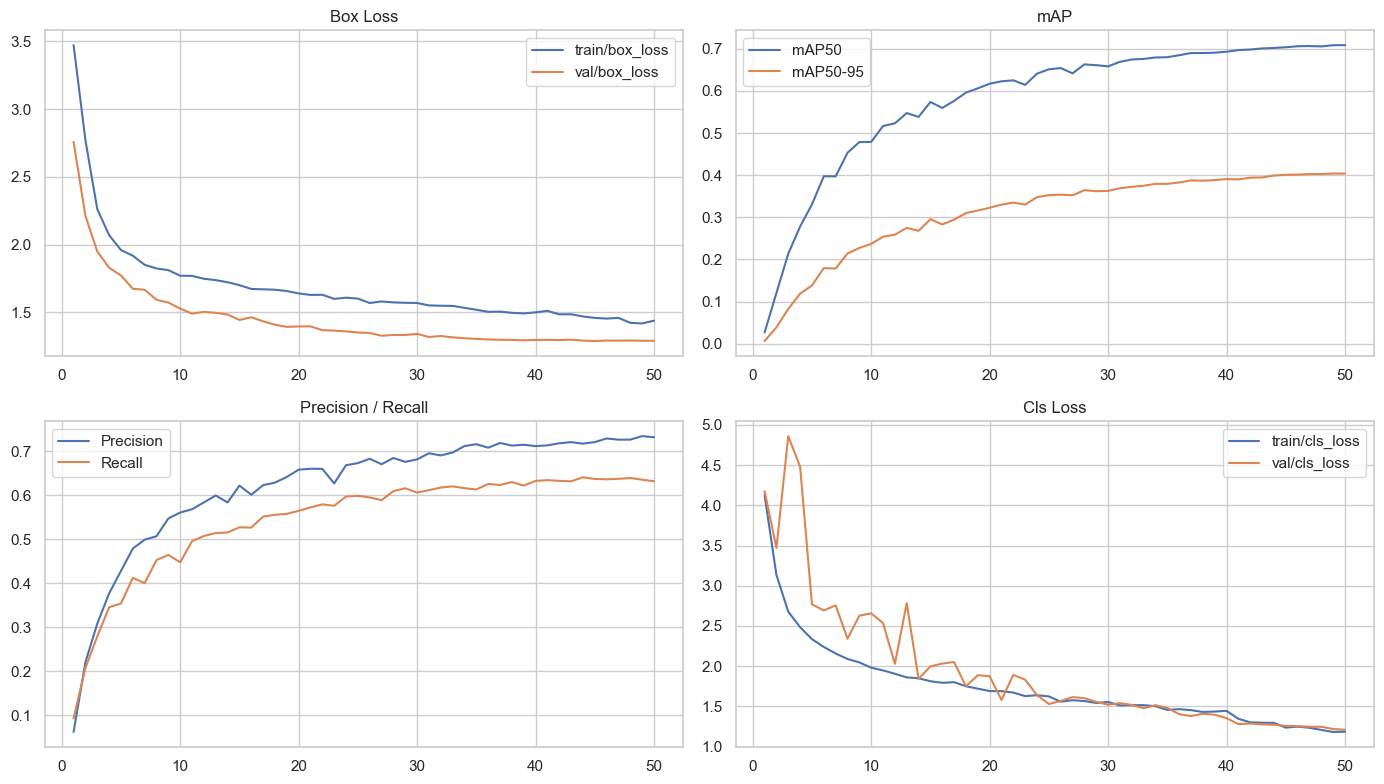

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/results.csv")
df = pd.read_csv(csv_path)
display(df.tail())

plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.legend(); plt.title("Box Loss")

plt.subplot(2,2,2)
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.legend(); plt.title("mAP")

plt.subplot(2,2,3)
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.legend(); plt.title("Precision / Recall")

plt.subplot(2,2,4)
plt.plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
plt.legend(); plt.title("Cls Loss")

plt.tight_layout()
plt.show()

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 436.2±288.4 MB/s, size: 203.7 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels... 3094 images, 1375 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 730.7it/s 4.2s<0.0s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg'
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg'
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detec

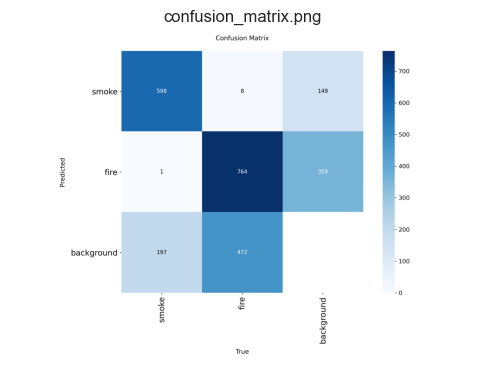

In [18]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

best_w = "/kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/weights/best.pt"
model_best = YOLO(best_w)

metrics = model_best.val(
    data="/kaggle/working/data_fire.yaml",
    split="val",
    imgsz=640,
    device=0
)
print(metrics)

eval_dir = Path("/kaggle/working/runs/fire_smoke_yolo11n_scratch_es3")
for fn in ["confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    p = eval_dir / fn
    if p.exists():
        plt.figure(figsize=(6,6))
        plt.imshow(Image.open(p))
        plt.title(fn)
        plt.axis("off")
        plt.show()

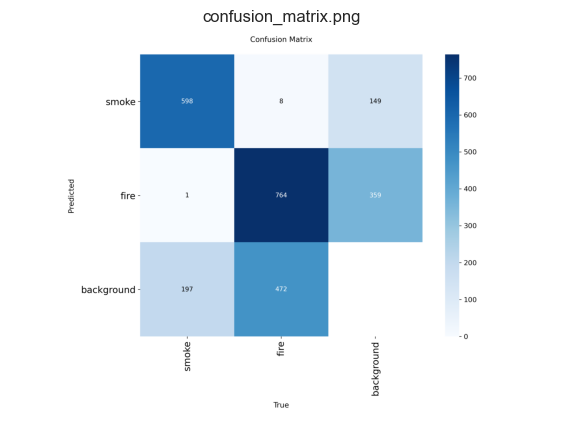

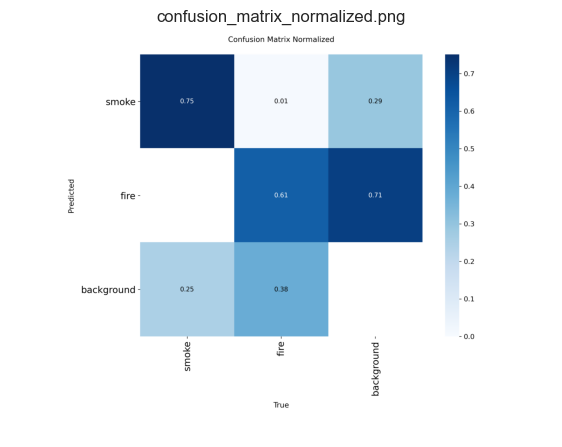

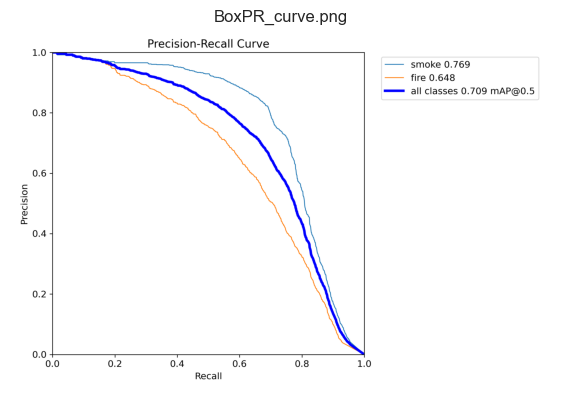

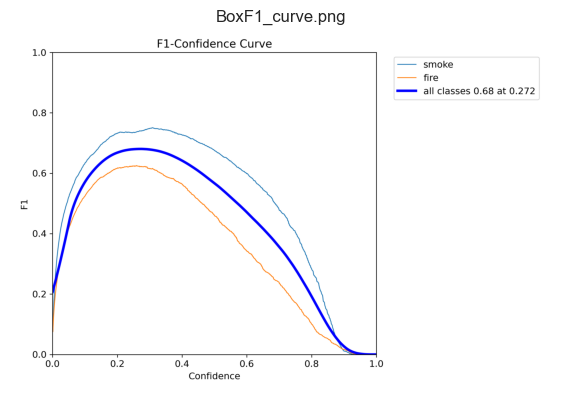

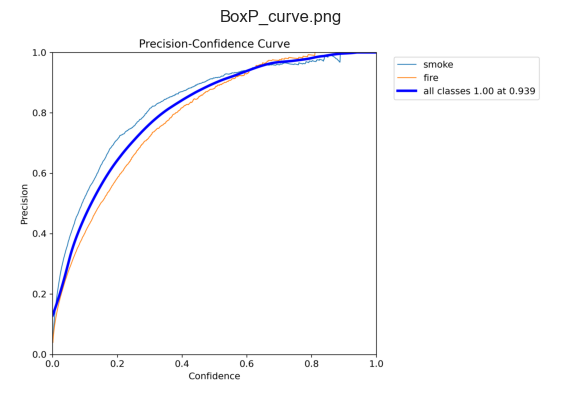

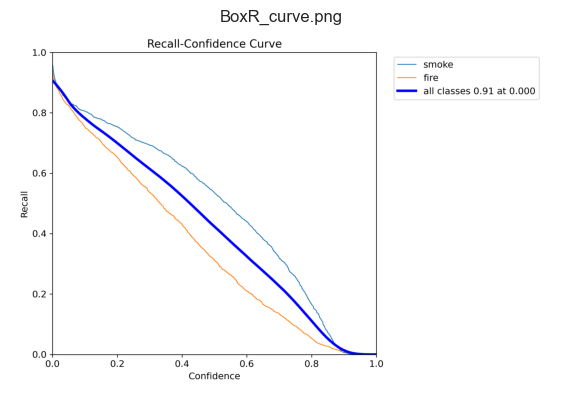

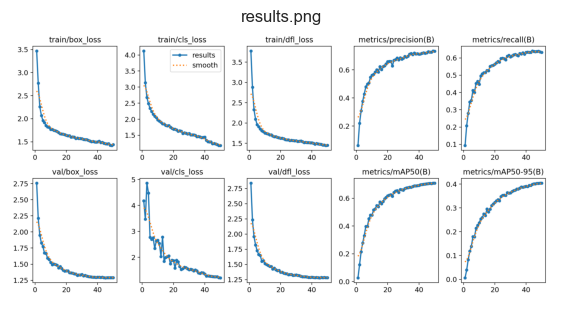

In [19]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

eval_dir = Path("/kaggle/working/runs/fire_smoke_yolo11n_scratch_es3")

# đúng theo output bạn đã liệt kê
metric_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "results.png"
]

for fn in metric_files:
    p = eval_dir / fn
    if p.exists():
        plt.figure(figsize=(7,6))
        plt.imshow(Image.open(p))
        plt.title(fn)
        plt.axis("off")
        plt.show()
    else:
        print("Not found:", p)

Testing image: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10868.jpg | exists: True

image 1/1 /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10868.jpg: 384x640 1 smoke, 3 fires, 54.6ms
Speed: 1.6ms preprocess, 54.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


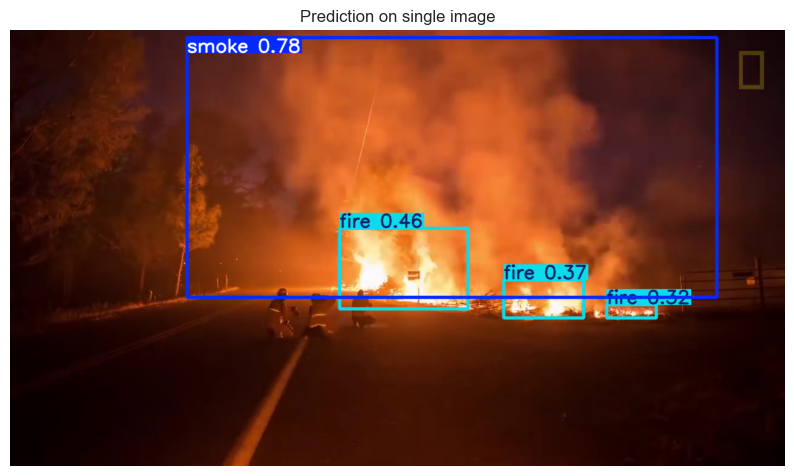

1. class=smoke conf=0.783 bbox_xyxy=[     292.86      12.639      1167.4      441.91]
2. class=fire conf=0.464 bbox_xyxy=[     544.28      327.87      756.11      460.07]
3. class=fire conf=0.371 bbox_xyxy=[     815.79      412.62      947.85      475.93]
4. class=fire conf=0.323 bbox_xyxy=[     985.28      453.34      1067.1      475.49]


In [20]:
# =========================================================
# TEST 1 ẢNH CỤ THỂ
# =========================================================
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# 1) Load model best
model = YOLO("/kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/weights/best.pt")

# 2) Chọn ảnh cụ thể (đổi filename theo ảnh bạn muốn test)
img_path = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10868.jpg"

# Nếu không chắc tên file, chạy 2 dòng này để lấy nhanh 1 ảnh:
# from glob import glob
# img_path = sorted(glob("/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/*"))[0]

print("Testing image:", img_path, "| exists:", Path(img_path).exists())

# 3) Predict
results = model.predict(
    source=img_path,
    imgsz=640,
    conf=0.25,
    iou=0.5,
    save=False,        # không lưu file
    device=0
)

# 4) Vẽ kết quả lên ảnh
annotated = results[0].plot()  # BGR image
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.title("Prediction on single image")
plt.axis("off")
plt.show()

# 5) In chi tiết box + confidence
boxes = results[0].boxes
if boxes is None or len(boxes) == 0:
    print("No detections.")
else:
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()
    xyxy = boxes.xyxy.cpu().numpy()

    names = results[0].names  # {0:'smoke',1:'fire'}
    for i, (c, cf, bb) in enumerate(zip(cls_ids, confs, xyxy), 1):
        print(f"{i}. class={names[c]} conf={cf:.3f} bbox_xyxy={bb}")

In [22]:
# =========================================================
# CELL 14: QUICK ANALYSIS
# =========================================================
# nếu bạn đã có df rồi thì:
res = df  # hoặc bỏ dòng này và thay res -> df bên dưới

last = res.iloc[-1]
print("Last epoch metrics:")
print(last[["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]])

print("\nGợi ý đọc kết quả:")
print("- Nếu train loss giảm nhưng val mAP đứng/giảm => có dấu hiệu overfitting.")
print("- Nếu cả train/val loss còn cao, mAP thấp => underfitting (epochs ít, model nhỏ, hoặc augment quá mạnh).")
print("- Xem confusion_matrix.png để biết smoke hay fire bị nhầm nhiều hơn.")

Last epoch metrics:
metrics/precision(B)    0.73210
metrics/recall(B)       0.63194
metrics/mAP50(B)        0.70877
metrics/mAP50-95(B)     0.40387
Name: 49, dtype: float64

Gợi ý đọc kết quả:
- Nếu train loss giảm nhưng val mAP đứng/giảm => có dấu hiệu overfitting.
- Nếu cả train/val loss còn cao, mAP thấp => underfitting (epochs ít, model nhỏ, hoặc augment quá mạnh).
- Xem confusion_matrix.png để biết smoke hay fire bị nhầm nhiều hơn.


In [23]:
# =========================================================
# CELL 15: IMPROVEMENT PLAN
# =========================================================
improvements = [
    "1) Train lâu hơn: 50-100 epochs (ngoài Kaggle hoặc resume nhiều session).",
    "2) Thử model lớn hơn: yolo11s.pt / yolo11m.pt nếu GPU đủ.",
    "3) Tối ưu threshold theo mục tiêu cảnh báo sớm: giảm conf để tăng recall.",
    "4) Bổ sung hard data: khói mỏng, đêm, ngược sáng, khoảng cách xa.",
    "5) Làm error mining: thu thập ảnh false positive/false negative để retrain.",
    "6) Deploy real-time: export ONNX/TensorRT + pipeline camera OpenCV + rule cảnh báo N frame liên tiếp."
]
print("\n".join(improvements))

1) Train lâu hơn: 50-100 epochs (ngoài Kaggle hoặc resume nhiều session).
2) Thử model lớn hơn: yolo11s.pt / yolo11m.pt nếu GPU đủ.
3) Tối ưu threshold theo mục tiêu cảnh báo sớm: giảm conf để tăng recall.
4) Bổ sung hard data: khói mỏng, đêm, ngược sáng, khoảng cách xa.
5) Làm error mining: thu thập ảnh false positive/false negative để retrain.
6) Deploy real-time: export ONNX/TensorRT + pipeline camera OpenCV + rule cảnh báo N frame liên tiếp.


In [24]:
!zip -r /kaggle/working/fire_smoke_yolo11n_scratch.zip /kaggle/working/runs/fire_smoke_yolo11n_scratch_es3

  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/ (stored 0%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/weights/ (stored 0%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/weights/last.pt (deflated 10%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/weights/best.pt (deflated 10%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/train_batch35282.jpg (deflated 16%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/train_batch35280.jpg (deflated 16%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/val_batch0_labels.jpg (deflated 11%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/confusion_matrix_normalized.png (deflated 31%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/BoxF1_curve.png (deflated 12%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/train_batch2.jpg (deflated 14%)
  adding: kaggle/working/runs/fire_smoke_yolo11n_scratch_es3/train_batch1.j